In [86]:
import matplotlib.pyplot
import pandas
from chronos import Chronos2Pipeline

import glob
import re
from cycler import cycler

In [87]:
def read_summary_as_csv(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'core', 'event', 'value', 'enabled', 'running']
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index('timestamp_ns').sort_index().fillna(1.0)

def transform_summary_csv(data_frame : pandas.DataFrame) -> pandas.DataFrame:
    wide_data_frame = data_frame.pivot_table(
        index=data_frame.index,
        columns=['core', 'event'],
        values=['value', 'enabled', 'running'],
    )
    scaled_data_frame = wide_data_frame['value'] * wide_data_frame['enabled'] / wide_data_frame['running']
    resampled_data_frame = scaled_data_frame.T.groupby(level='event').sum().T.sort_index(axis=1).resample("100ms").mean().diff()

    # resample() leaves a gap wherever a 100ms bin had no underlying samples, which breaks
    # downstream frequency inference (e.g. Chronos). Reindex onto a fully regular 100ms grid
    # and interpolate those gaps away so every step is exactly 100ms apart.
    full_index = pandas.date_range(resampled_data_frame.index.min(), resampled_data_frame.index.max(), freq="100ms")
    return resampled_data_frame.reindex(full_index).interpolate(method='time').rename_axis('timestamp_ns')

def parse_vegeta_as_csv(file_path : str) -> pandas.DataFrame:
    columns : list[str] = ['timestamp_ns', 'status', 'latency_ns']
    log_files = sorted(
        glob.glob(f"{file_path}/*vegeta*.log"),
        key=lambda name: int(re.search(r"vegeta(\d+)\.log$", name).group(1)),
    )
    data_frames : list[pandas.DataFrame] = [
        pandas.read_csv(log_file, usecols=[0, 1, 2], header=None, names=columns)
        for log_file in log_files
    ]
    combined_data_frame : pandas.DataFrame = pandas.concat(data_frames, ignore_index=True)

    combined_data_frame['timestamp_ns'] = pandas.to_datetime(combined_data_frame['timestamp_ns'], unit='ns')
    combined_data_frame = combined_data_frame.set_index('timestamp_ns').sort_index()

    #return combined_data_frame['latency_ns'].resample('1s').quantile(0.99).expanding().mean() / 1e6
    return combined_data_frame['latency_ns'].resample('100ms').quantile(0.99) / 1e6

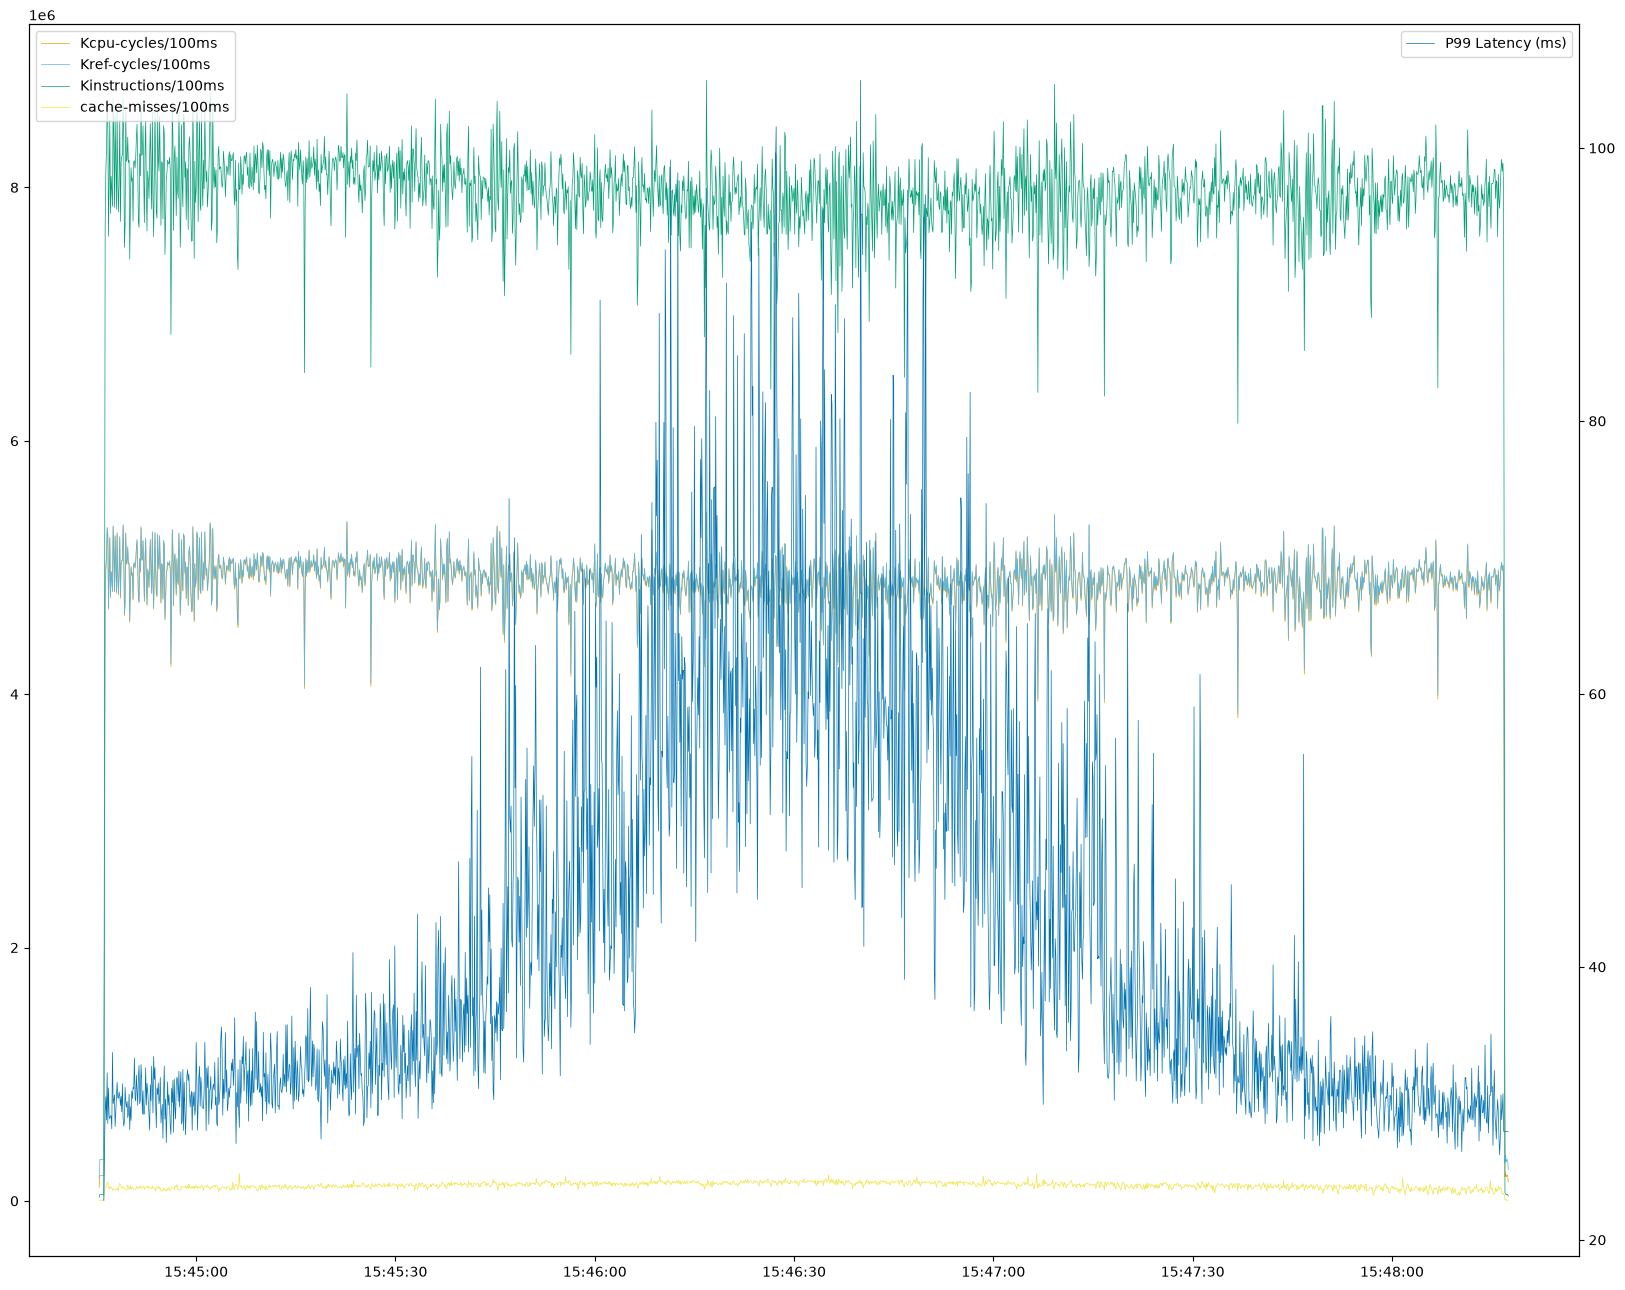

In [88]:
subdirectory=""

probe_data_frame  = transform_summary_csv(read_summary_as_csv(f"results/{subdirectory}summary.log"))

p99_latency_ms = parse_vegeta_as_csv(f"results/{subdirectory}")
# reindex(method='ffill') only fills index labels absent from p99_latency_ms; it does NOT
# propagate through NaN values already present at matching labels (e.g. 100ms bins with no
# requests). Chain a separate ffill() to actually carry the last known value forward.
probe_data_frame['p99_latency_ms'] = p99_latency_ms.reindex(probe_data_frame.index).ffill()

figure, laxis = matplotlib.pyplot.subplots(figsize=(20, 16))
raxis = laxis.twinx()

laxis.set_prop_cycle(cycler(color=["#E69F00", "#56B4E9", "#009E73", "#F0E442"]))
raxis.set_prop_cycle(cycler(color=["#0072B2", "#D55E00", "#CC79A7", "#000000"]))

laxis.plot(probe_data_frame['cpu-cycles'] / 1e3,     label="Kcpu-cycles/100ms",   linewidth=0.5)
laxis.plot(probe_data_frame['ref-cpu-cycles'] / 1e3, label="Kref-cycles/100ms",   linewidth=0.5)
laxis.plot(probe_data_frame['instructions'] / 1e3,   label="Kinstructions/100ms", linewidth=0.5)
laxis.plot(probe_data_frame['cache-misses'],         label="cache-misses/100ms",  linewidth=0.5)

raxis.plot(probe_data_frame['p99_latency_ms'], label="P99 Latency (ms)", linewidth=0.5)

laxis.legend(loc="upper left")
raxis.legend(loc="upper right")

In [100]:
prediction_length = 1000

model_data_frame = probe_data_frame.dropna().reset_index().rename(columns={'timestamp_ns': 'timestamp'})
model_data_frame['item_id'] = "worker0"

train_data_frame = model_data_frame.iloc[:-prediction_length]
test_data_frame = model_data_frame.iloc[-prediction_length:]

In [101]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2")

# All columns other than 'p99_latency_ms' (the perf/network counters) are passed through as
# past-only covariates, since their future values aren't known ahead of time.
forecast_data_frame = pipeline.predict_df(
    train_data_frame,
    id_column="item_id",
    timestamp_column="timestamp",
    target="p99_latency_ms",
    prediction_length=prediction_length,
)

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 8529.90it/s]


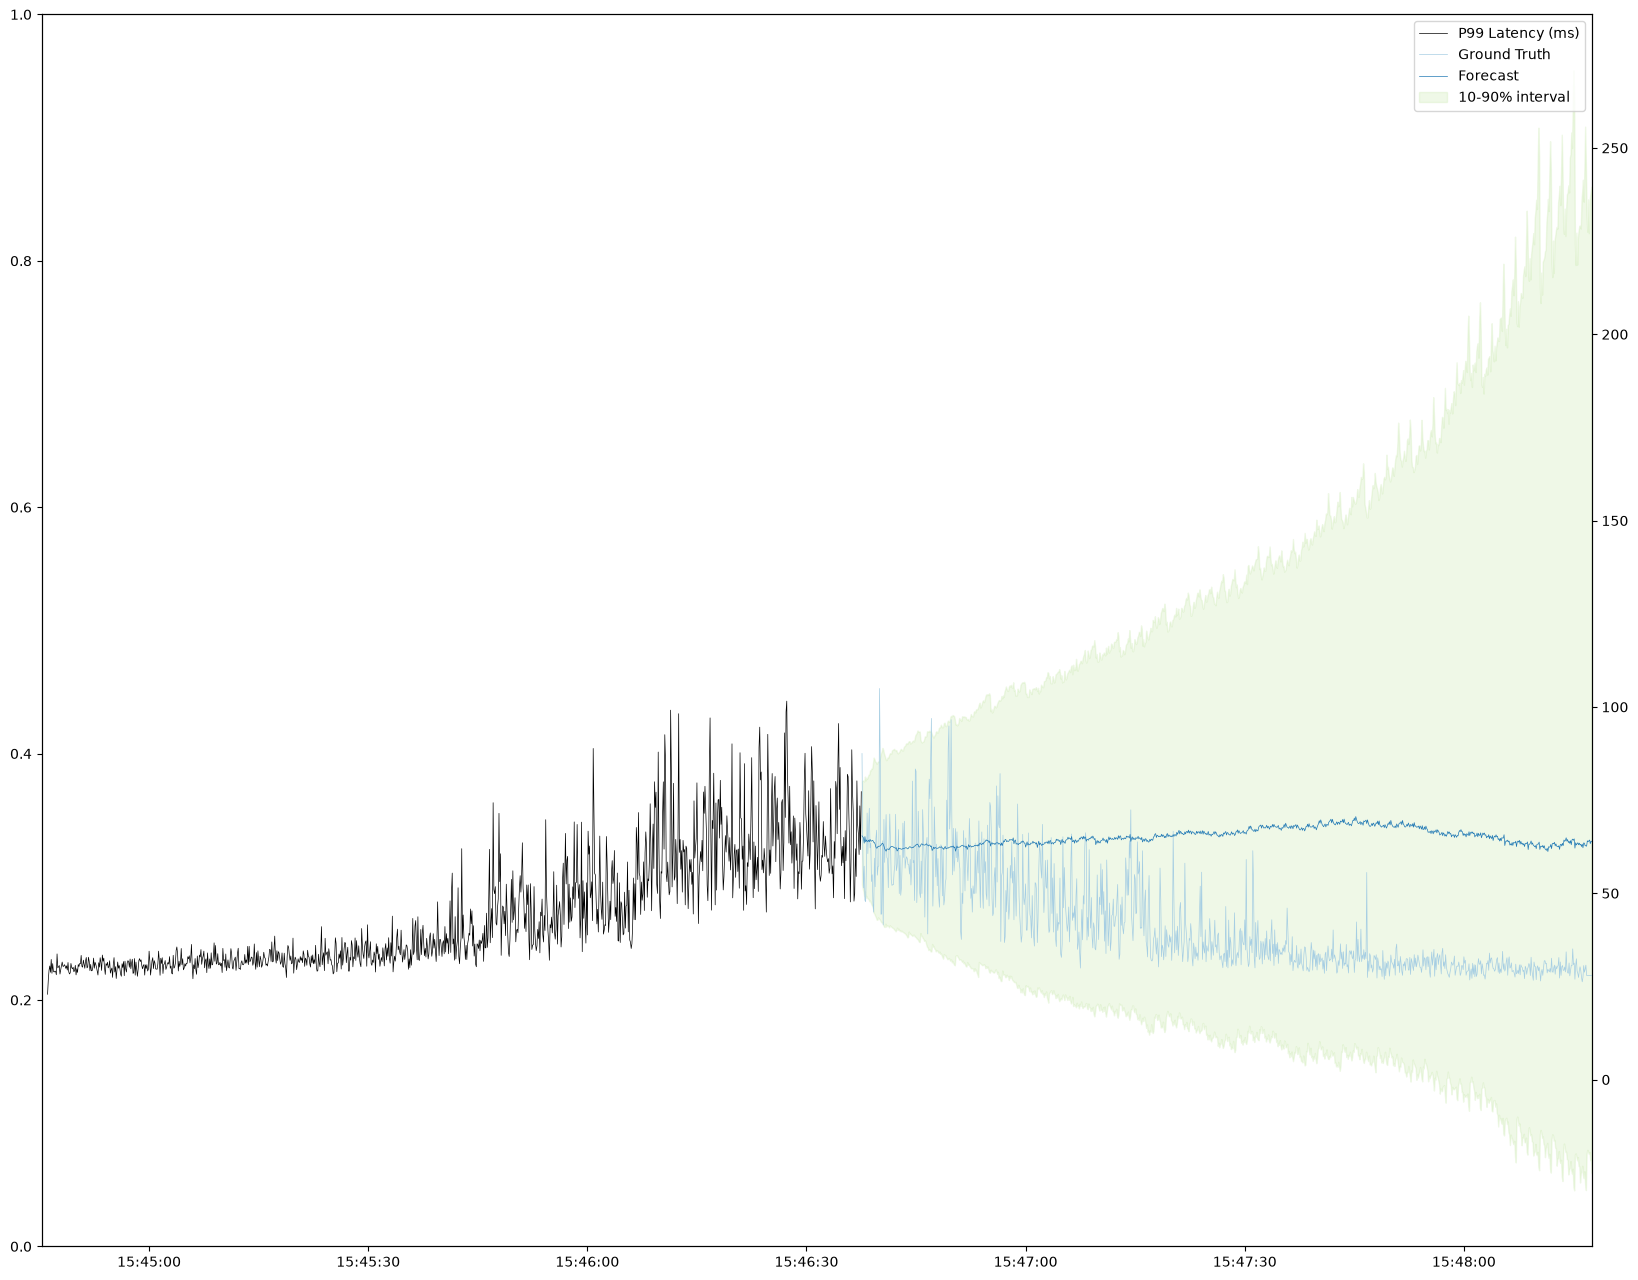

In [102]:
figure, laxis = matplotlib.pyplot.subplots(figsize=(20, 16))
raxis = laxis.twinx()

laxis.set_prop_cycle(cycler(color=["#E69F00", "#56B4E9", "#009E73", "#F0E442"]))

#laxis.plot(probe_data_frame['cpu-cycles'] / 1e3,     label="Kcpu-cycles/100ms")
#laxis.plot(probe_data_frame['ref-cpu-cycles'] / 1e3, label="Kref-cycles/100ms")
#laxis.plot(probe_data_frame['instructions'] / 1e3,   label="Kinstructions/100ms")
#laxis.plot(probe_data_frame['cache-misses'],         label="cache-misses/100ms")

raxis.plot(train_data_frame['timestamp'],    train_data_frame['p99_latency_ms'], label="P99 Latency (ms)", linewidth=0.5, color="#000000")
raxis.plot(test_data_frame['timestamp'],     test_data_frame['p99_latency_ms'],  label="Ground Truth", linewidth=0.5, color="#a6cee3")
raxis.plot(forecast_data_frame['timestamp'], forecast_data_frame['predictions'], label="Forecast", linewidth=0.5, color="#1f78b4")
raxis.fill_between(
    forecast_data_frame['timestamp'],
    forecast_data_frame['0.1'],
    forecast_data_frame['0.9'],
    color="#b2df8a",
    alpha=0.2,
    label="10-90% interval",
)

# twinx() shares the x-axis, so whichever axes autoscales last wins the shared xlim. Pin it
# explicitly to the full data range (probe history through the end of the forecast) so the
# P99 series doesn't get clipped to just its own plotted span.
laxis.set_xlim(probe_data_frame.index.min(), forecast_data_frame['timestamp'].max())

#laxis.legend(loc="upper left")
raxis.legend(loc="upper right")